--- First Run (Baseline) h = 0.01 ---
This run is saved as the baseline to compare future errors against.

--- Run with h = 0.06 ---
Point-by-point errors: [0.     0.0048 0.0084 0.0111 0.0131 0.0144 0.0153 0.0157 0.0159 0.0158
 0.0154 0.015  0.0144 0.0138 0.0131 0.0124 0.0117 0.0109 0.0102 0.0095
 0.0088 0.0082 0.0076 0.007  0.0064 0.0059 0.0054 0.005  0.0045 0.0042
 0.0038 0.0035 0.0032 0.0029]
Total accumulated error: 0.3173

--- Run with h = 0.11 ---
Point-by-point errors: [0.     0.019  0.0299 0.0354 0.0373 0.0368 0.0349 0.0321 0.029  0.0258
 0.0226 0.0196 0.0169 0.0145 0.0123 0.0104 0.0088 0.0074 0.0062]
Total accumulated error: 0.3988

--- Run with h = 0.16 ---
Point-by-point errors: [0.     0.0341 0.0476 0.0497 0.0463 0.0403 0.0338 0.0275 0.0219 0.0172
 0.0134 0.0103 0.0078]
Total accumulated error: 0.3498

--- Run with h = 0.21 ---
Point-by-point errors: [0.     0.0876 0.1093 0.1024 0.0855 0.067  0.0505 0.037  0.0267 0.0189
 0.0133]
Total accumulated error: 0.5982

--- Run with

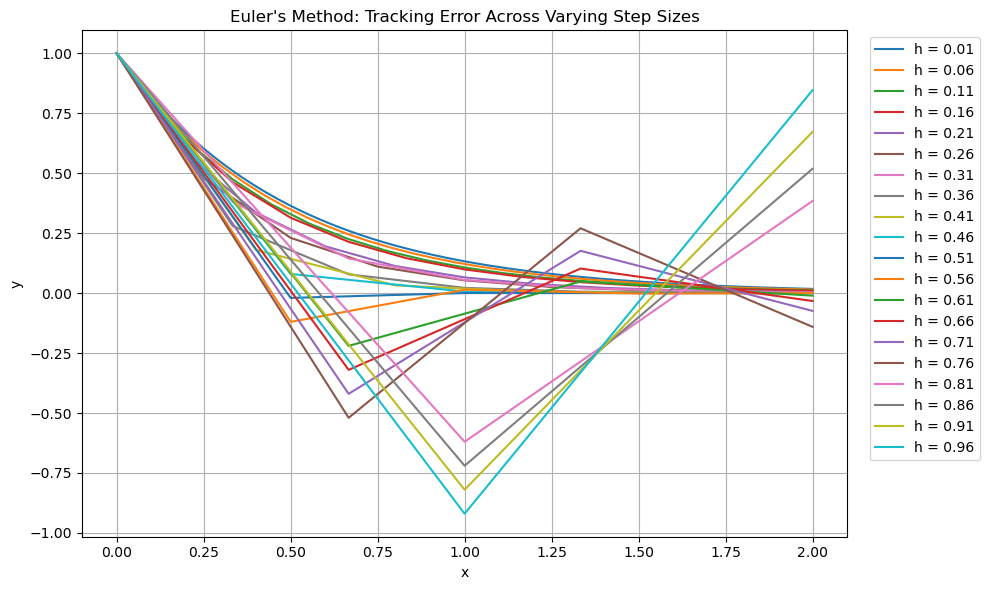

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2
step_sizes = np.arange(0.01, 1.01, 0.05)

x_first = None
y_first = None

def f(x, y):
    return -2 * y

plt.figure(figsize=(10, 6))
for idx, h in enumerate(step_sizes):
    num_steps = int(np.round((x_end - x_start) / h))
    
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1  # Initial condition y(0) = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    if idx == 0:
        x_first = x_values
        y_first = y_values
        print(f"--- First Run (Baseline) h = {h:.2f} ---")
        print("This run is saved as the baseline to compare future errors against.\n")
    else:
        y_baseline_matched = np.interp(x_values, x_first, y_first)
        point_errors = np.abs(y_values - y_baseline_matched)
        total_error = np.sum(point_errors)
        print(f"--- Run with h = {h:.2f} ---")
        print(f"Point-by-point errors: {np.round(point_errors, 4)}")
        print(f"Total accumulated error: {total_error:.4f}\n")
    plt.plot(x_values, y_values, label=f"h = {h:.2f}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method: Tracking Error Across Varying Step Sizes")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()